# Type-1 Frozen-Trigger Scan

This notebook runs `coupling_type = 1` through the local `./class` executable, without the Python `classy` wrapper.

The target here is: initially frozen field, small bare axion mass, and onset driven by the DM/EDE coupling. The important input is `scf_parameters = theta_i, theta_prime_i`; for the axion branch the code later multiplies both entries by `f_axion`. Therefore `scf_parameters = 2.72,-1` means `phi_prime_i = -f_axion`, not a frozen field. The scan below uses `theta_prime_i = 0`.

Caveat for the `(1-cos theta)^n` potential: with `m_axion ~ H0`, the potential height scales like `m^2 f_axion^2`. A large visible EDE fraction near equality requires a very large `f_axion`, but the type-1 coupling is written as a function of `phi` in reduced-Planck units, so large `phi = f_axion theta` suppresses `d ln m / d phi`. The last cell estimates this tension.

In [1]:
from pathlib import Path
import datetime as dt
import math
import subprocess
import textwrap

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f"matplotlib unavailable: {exc}")

repo = Path.cwd()
if not (repo / "class").exists() and (repo.parent / "class").exists():
    repo = repo.parent

assert (repo / "source" / "background.c").exists(), repo
(repo / "output").mkdir(exist_ok=True)
print(repo)


/Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling


In [2]:
# Build only the C executable. This avoids the Python wrapper/distutils path.
subprocess.run(["make", "class"], cwd=repo, check=True)


make: `class' is up to date.


CompletedProcess(args=['make', 'class'], returncode=0)

In [3]:
# Frozen initial condition and small bare mass.
theta_i = 2.72
theta_prime_i = 0.0
n_axion = 3
f_axion = 1.704135e-01
m_axion = 1.0

# g ~ 0.05 gives first substantial displacement near equality for this small-f qualitative run.
# g ~ 0.3 makes the effective coupling curvature order unity around equality, but the field starts drifting earlier.
g_values = [0.0, 0.03, 0.05, 0.1, 0.3, 1.0]

omega_ini_idm_ede = 0.12
h0 = 72.81
stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")


In [4]:
def tag_number(x):
    return f"{x:.4g}".replace("-", "m").replace(".", "p")


def ini_text(g, root):
    return f"""
root = {root}
output = tCl
write background = yes
write parameters = yes
compute_sigma8 = no
omega_b = 0.02251
omega_ini_idm_ede = {omega_ini_idm_ede}
H0 = {h0}
tau_reio = 0.068
A_s = 2.191e-9
n_s = 0.9860

coupling_type = 1
g_idm_ede = {g}

N_ur = 2.0328
N_ncdm = 1
deg_ncdm = 1
m_ncdm = 0.06
T_ncdm = 0.71611

scf_potential = axion
n_axion = {n_axion}
scf_parameters = {theta_i},{theta_prime_i}
f_axion = {f_axion}
m_axion = {m_axion}

scf_evolve_as_fluid = no
scf_evolve_as_fluid_always = no
scf_evolve_like_axionCAMB = no
do_shooting = yes
do_shooting_scf = no
scf_has_perturbations = no
attractor_ic_scf = no
loop_over_background_for_closure_relation = no

modes = s
gauge = synchronous
lensing = no

input_verbose = 0
background_verbose = 0
thermodynamics_verbose = 0
perturbations_verbose = 0
transfer_verbose = 0
primordial_verbose = 0
spectra_verbose = 0
nonlinear_verbose = 0
lensing_verbose = 0
output_verbose = 0
"""


def run_model(g):
    tag = tag_number(g)
    root = repo / "output" / f"type1_frozen_scan_{stamp}_g{tag}_"
    ini_path = Path("/tmp") / f"type1_frozen_scan_{stamp}_g{tag}.ini"
    ini_path.write_text(textwrap.dedent(ini_text(g, root)).strip() + "\n")
    run = subprocess.run([str(repo / "class"), str(ini_path)], cwd=repo, text=True, capture_output=True)
    if run.returncode != 0:
        print(run.stdout[-4000:])
        print(run.stderr[-4000:])
        raise RuntimeError(f"CLASS failed for g={g} with return code {run.returncode}")
    bg_files = sorted(root.parent.glob(root.name + "*background.dat"), key=lambda p: p.stat().st_mtime)
    if not bg_files:
        raise FileNotFoundError(f"No background file found for {root}")
    return bg_files[-1]


def read_background(path):
    rows = []
    with open(path) as handle:
        for line in handle:
            if line.startswith("#") or not line.strip():
                continue
            rows.append([float(x) for x in line.split()])
    return rows


def nearest_row(rows, z_target):
    target = math.log1p(z_target)
    return min(rows, key=lambda row: abs(math.log1p(row[0]) - target))


def phi_N(row):
    z = row[0]
    a = 1.0 / (1.0 + z)
    H = row[3]
    return row[24] / (a * H) if a * H else float("nan")


def z_for_fractional_phi_shift(rows, frac=0.1):
    phi0 = rows[0][23]
    scale = max(abs(phi0), 1e-300)
    for row in rows:
        if abs(row[23] - phi0) > frac * scale:
            return row[0]
    return None


In [5]:
results = {}
for g in g_values:
    bg_path = run_model(g)
    results[g] = read_background(bg_path)
    print(f"g={g:g}: {bg_path}")


g=0: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g0_00_background.dat
g=0.03: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g0p03_00_background.dat
g=0.05: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g0p05_00_background.dat
g=0.1: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g0p1_00_background.dat
g=0.3: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g0p3_00_background.dat
g=1: /Users/vpoulin/Dropbox/Labo/ProgrammeCMB/AxiCLASS_EDE_DM_coupling/output/type1_frozen_scan_20260424_094810_g1_00_background.dat


In [6]:
print(f"{'g':>7} {'z_10pct':>11} {'trig_eq':>11} {'phiN_eq':>11} {'w_eq':>9} {'Omega_eq':>11} {'phi_eq':>11} {'phi_today':>11}")
summary = {}
for g, rows in results.items():
    eq = nearest_row(rows, 3400.0)
    today = nearest_row(rows, 0.0)
    z10 = z_for_fractional_phi_shift(rows, 0.1)
    summary[g] = {"eq": eq, "today": today, "z10": z10}
    z10_text = "none" if z10 is None else f"{z10:.3g}"
    print(f"{g:7.3g} {z10_text:>11} {eq[29]:11.3g} {phi_N(eq):11.3g} {eq[21]:9.3g} {eq[18]:11.3g} {eq[23]:11.3g} {today[23]:11.3g}")


      g     z_10pct     trig_eq     phiN_eq      w_eq    Omega_eq      phi_eq   phi_today
      0       0.301    5.25e-11   -5.19e-12        -1    2.15e-12       0.464       0.369
   0.03         698      0.0507     -0.0131         1    2.87e-05       0.443       0.235
   0.05    1.98e+03      0.0842     -0.0213         1    7.58e-05        0.43       0.194
    0.1    5.69e+03       0.167       -0.04         1    0.000267       0.398      0.0975
    0.3    2.08e+04       0.484      -0.094         1     0.00147       0.293   -0.000782
      1    6.57e+04        1.47      -0.139         1      0.0032      0.0848   -5.55e-05


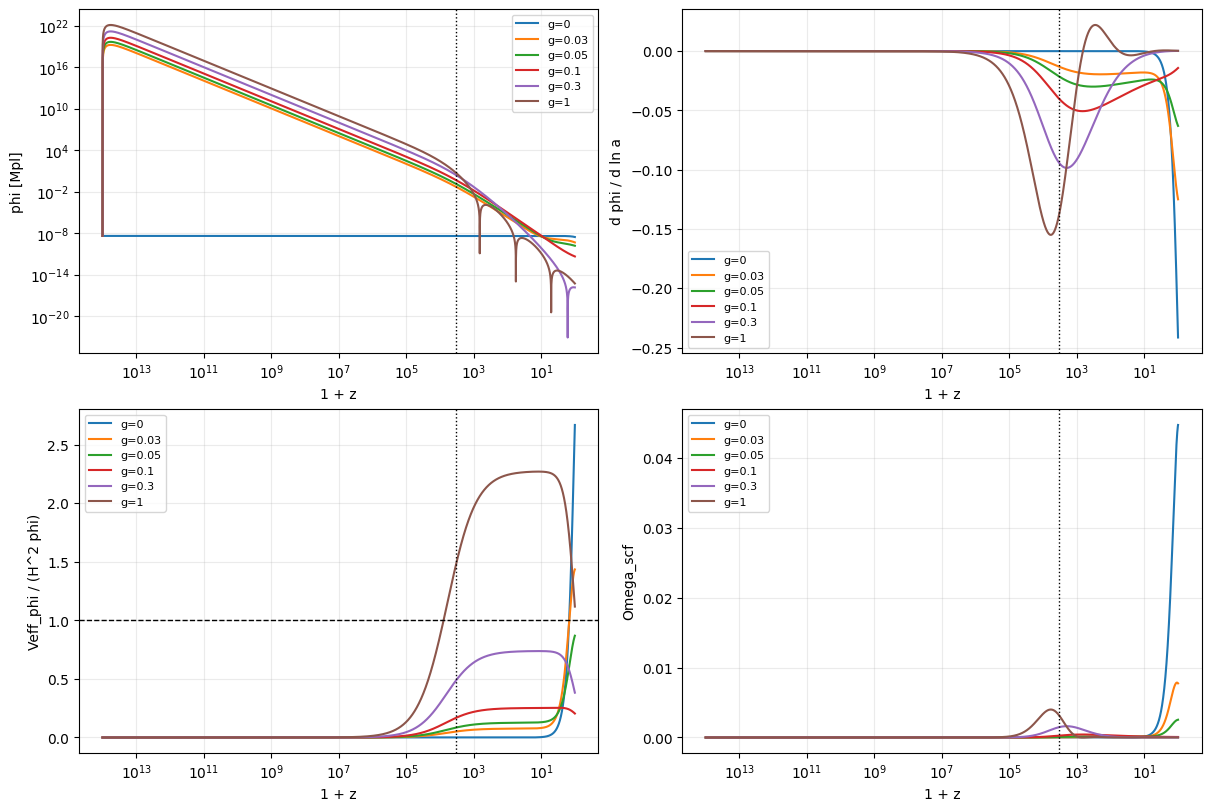

In [11]:
if plt is None:
    print("Install matplotlib to get plots; the table above is still usable.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    for g, rows in results.items():
        x = [1.0 + row[0] for row in rows]
        axes[0, 0].loglog(x, [row[17] for row in rows], label=f"g={g:g}")
        axes[0, 1].semilogx(x, [phi_N(row) for row in rows], label=f"g={g:g}")
        axes[1, 0].semilogx(x, [row[29] for row in rows], label=f"g={g:g}")
        axes[1, 1].semilogx(x, [row[18] for row in rows], label=f"g={g:g}")

    axes[0, 0].set_ylabel("phi [Mpl]")
    axes[0, 1].set_ylabel("d phi / d ln a")
    axes[1, 0].set_ylabel("Veff_phi / (H^2 phi)")
    axes[1, 1].set_ylabel("Omega_scf")

    for axis in axes.flat:
        axis.axvline(1.0 + 3400.0, color="k", ls=":", lw=1)
        axis.invert_xaxis()
        axis.grid(True, alpha=0.25)
        axis.set_xlabel("1 + z")
        axis.legend(fontsize=8)

    axes[1, 0].axhline(1.0, color="k", ls="--", lw=1)
    plt.show()


In [8]:
# Height/coupling consistency estimate for the chosen (1-cos)^n potential.
# This is why m_axion ~ H0 cannot give an observable EDE fraction at equality with moderate f_axion.
target_Omega_eq = 0.1
reference_rows = next(iter(results.values()))
eq = nearest_row(reference_rows, 3400.0)
today = nearest_row(reference_rows, 0.0)
H0_code = today[3]
H2_eq = eq[16]
Omega_idm_eq = eq[15] / eq[16]
shape = (1.0 - math.cos(theta_i)) ** n_axion
f_needed = math.sqrt(target_Omega_eq * H2_eq / ((m_axion * H0_code) ** 2 * shape))
phi_needed = theta_i * f_needed
max_trigger_eq = 6.0 * Omega_idm_eq / (phi_needed ** 2)

print(f"For Omega_scf(z_eq) ~ {target_Omega_eq:g} with m_axion={m_axion:g}, this potential needs f_axion ~ {f_needed:.3g} Mpl.")
print(f"Then phi_i ~ {phi_needed:.3g} Mpl, and even the large-g saturation of 6 Omega_idm/phi^2 gives only {max_trigger_eq:.3g} at equality.")
print("So an observable equality-era EDE fraction with m_axion ~ H0 is not compatible with this phi-based type-1 coupling unless the potential normalization is decoupled from m^2 f^2 or the coupling is redefined in terms of theta=phi/f.")


For Omega_scf(z_eq) ~ 0.1 with m_axion=1, this potential needs f_axion ~ 2.07e+04 Mpl.
Then phi_i ~ 5.64e+04 Mpl, and even the large-g saturation of 6 Omega_idm/phi^2 gives only 5.36e-10 at equality.
So an observable equality-era EDE fraction with m_axion ~ H0 is not compatible with this phi-based type-1 coupling unless the potential normalization is decoupled from m^2 f^2 or the coupling is redefined in terms of theta=phi/f.
